## PROJECT BY SAMUEL NNAMANI a.k.a Sammyst The Analyst

### PROBLEM STATEMENT

To predict the prices of houses using Machine Learning model, in this instance XGBRegressor.

### DATA SET DESCRIPTION
The dataset contain the characteristics and prices of homes in California Districts, as at 1990 U.S. Census. It contains 20,640 records spread across 8 features/columns such as 
1. MedInc(median income in block group),
2. HouseAge(median house age in block group),
3. AveRooms(average number of rooms per household),
4. AveBedrms(average number of bedrooms per household),
5. Population(block group population),
6. AveOccup(average number of household members),
7. Latitude(block group latitude),
8. Longitude(block group longitude)

NOTE:
1. A block group is the smallest geographical unit for which the U.S. Census Bureau publishes sample data (a block group typically has a population of 600 to 3,000 people). 
2. A household is a group of people residing within a home.

### IMPORT DEPENDENCIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

### FETCH THE DATASET

In [2]:
california_housing = fetch_california_housing()
print(california_housing)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]]), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset:\n\nCalifornia Housing dataset\n-

In [3]:
# Loading the dataset to a Pandas DataFrame

california_housing_df = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)

In [4]:
 # Add the target column(price) to the DataFrame
california_housing_df["Price"] = california_housing.target

In [5]:
# Calling out the Top 5 records of the dataset
california_housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
# Check the number of rows and columns in the dataset
california_housing_df.shape

(20640, 9)

In [7]:
# Check for missing values
california_housing_df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

### Thus the data is clean of missing values. 

In [8]:
# Check the statistical measures of the dataset
california_housing_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Understanding the correlation between the various features in the dataset

1. Positive Correlation
2. Negative Correlation

In [9]:
housing_correlation = california_housing_df.corr()

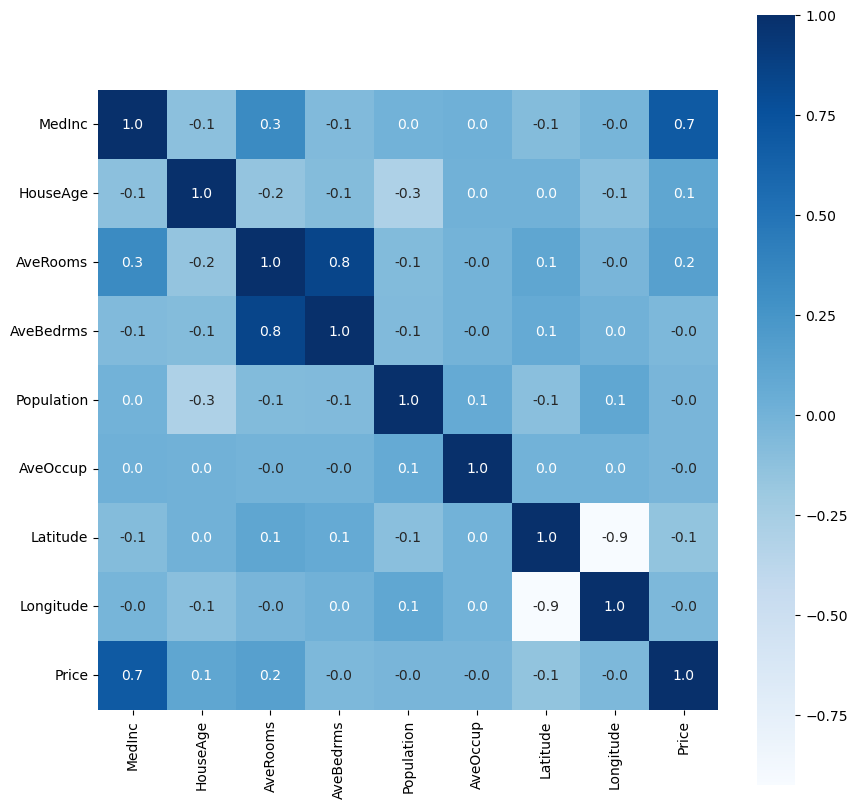

In [34]:
# Constructing a Heatmap to understand the correlation
plt.figure(figsize=(10,10))
sns.heatmap(housing_correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':10}, cmap="Blues")
plt.savefig("Correlation Heatmap.png")

### Splitting the data and Target

In [12]:
X = california_housing_df.drop("Price", axis=1)
Y = california_housing_df["Price"]

In [13]:
print(X)
print(Y)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

### Splitting the data into Training and Testing data

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2)

In [15]:
# Comparing the data sizes of the original data, the training data and the testing data
print(X.shape, X_train.shape, X_test.shape)

(20640, 8) (16512, 8) (4128, 8)


### Model Training

I am going to be using XGBoost Regressor because the data size is low.

In [20]:
# Load the model
xgb_model = XGBRegressor()

In [21]:
# Training the model with X_train
xgb_model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

### Evaluation

#### Prediction on training data

In [22]:
 # accuracy for prediction on training data
training_data_prediction = xgb_model.predict(X_train)

In [23]:
print(training_data_prediction)

[0.5523039 3.0850039 0.5835302 ... 1.9204227 1.952873  0.6768683]


In [24]:
# R Squared Error
score = metrics.r2_score(Y_train, training_data_prediction)

# Mean Absolute Error
score_1 = metrics.mean_absolute_error(Y_train, training_data_prediction)

print("R Squared Error: ", score)
print("Mean Absolute Error: ", score_1)

R Squared Error:  0.943650140819218
Mean Absolute Error:  0.1933648700612105


#### Visualizing the actual prices and the predicted prices

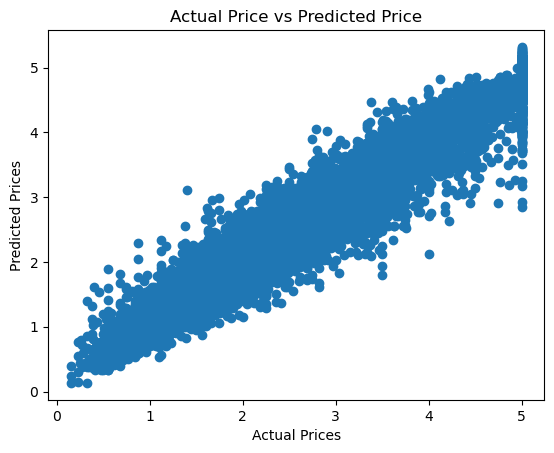

In [32]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Price vs Predicted Price")
plt.savefig("Actual Price vs Predicted Price(training).png")
plt.show()

#### Prediction on testing Data

In [26]:
# accuracy for prediction on test data
test_data_prediction = xgb_model.predict(X_test)

In [28]:
# R Squared Error
score = metrics.r2_score(Y_test, test_data_prediction)

# Mean Absolute Error
score_1 = metrics.mean_absolute_error(Y_test, test_data_prediction)

print("R Squared Error: ", score)
print("Mean Absolute Error: ", score_1)

R Squared Error:  0.8338000331788725
Mean Absolute Error:  0.3108631800268186


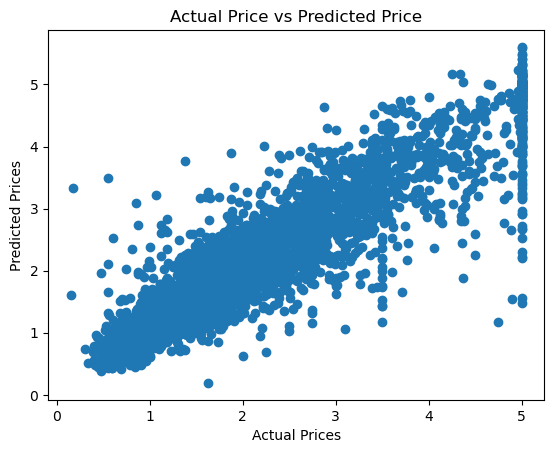

In [33]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Price vs Predicted Price")
plt.savefig("Actual Price vs Predicted Price(testing).png")
plt.show()